# Лабораторная работа 2

Дисциплина: АиСД

Студент: Емцова Анна Сергеевна

Группа: Базовая Группа

## 1. Цель работы

Цель КДЗ — экспериментально определить временную сложность различных алгоритмов сортировки в лучшем/среднем и худших случаях, выполнить сравнение для разных типов входных массивов и проанализировать полученные графики.

## 2. Рассматриваемые алгоритмы сортировки

1. Сортировка выбором

2. Пузырьковая (в лучше случае должно быть O(n) в этой реализации)

3. Простые вставки

4. Сортировка подсчетом (устойчивая)

5. Сортировка слиянием

6. Быстрая сортировка (опорный — первый элемент, разбиание Хоара)

7. Пирамидальная сортировка

8. Сортировка Шелла (последовательность Циура)

9. *** TimSort

Сделайте функции для сортировок, учтите, что нужно будет сделать функции дважды:
* для измерения времени
* и для измерения количества элементарных операций

In [1]:
# 1.1. Сортировка выбором: измерение времени
def select_sort(arr):
    n = len(arr)
    for i in range(0, n-1):
        min_idx = i
        for j in range(i+1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]

In [2]:
# 1.2. Сортировка выбором: измерение элементарных операций
def select_sort_ops(arr):
    n = len(arr)
    ops = 1

    for i in range(0, n-1):
        ops += 1

        min_idx = i
        ops += 1

        for j in range(i+1, n):
            ops += 1

            if arr[j] < arr[min_idx]:
                ops += 1

                min_idx = j
                ops += 1

        arr[i], arr[min_idx] = arr[min_idx], arr[i]
        ops += 3

    return ops


In [3]:
# 2.1. Сортировка пузырьком (условие Айверсона): измерение времени
def bubble_sort(arr):
    n = len(arr)
    i = 0
    t = True

    while t:
        t = False
        for j in range(0, n - i - 1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                t = True
        i = i + 1
    return arr

In [4]:
# 2.2. Сортировка пузырьком (условие Айверсона): измерение элементарных операций
def bubble_sort_ops(arr):
    n = len(arr)
    ops = 1

    i = 0
    ops += 1

    t = True
    ops += 1

    while t:
        ops += 1

        t = False
        ops += 1

        for j in range(0, n - i - 1):
            ops += 1

            if arr[j] > arr[j + 1]:
                ops += 1

                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                ops += 3

                t = True
                ops += 1

        i += 1
        ops += 1

    return ops


In [5]:
# 3.1. Сортировка вставкой: измерение времени
def insertion_sort(arr):
    n = len(arr)
    for i in range(1, n):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr


In [6]:
# 3.2. Сортировка вставкой: измерение элементарных операций
def insertion_sort_ops(arr):
    n = len(arr)
    ops = 1

    for i in range(1, n):
        ops += 1

        key = arr[i]
        ops += 1

        j = i - 1
        ops += 1

        while j >= 0 and key < arr[j]:
            ops += 2

            arr[j + 1] = arr[j]
            ops += 2

            j -= 1
            ops += 1

        ops += 2  # последняя проверка while

        arr[j + 1] = key
        ops += 2

    return ops


In [7]:
# 4.1. Сортировка подсчетом (устойчивая): измерение времени
def counting_sort(arr, k):
    n = len(arr)
    c = [0] * k

    for value in arr:
        c[value] += 1

    for i in range(1, k):
        c[i] += c[i - 1]

    result = [0] * n
    for i in range(n - 1, -1, -1):
        value = arr[i]
        c[value] -= 1
        result[c[value]] = value

    arr[:] = result
    return arr


In [8]:
# 4.2. Сортировка подсчетом (устойчивая): измерение элементарных операций
def counting_sort_ops(arr, k):
    n = len(arr)
    ops = 1

    c = [0] * k
    ops += 1

    for value in arr:
        ops += 1
        c[value] += 1
        ops += 2

    for i in range(1, k):
        ops += 1
        c[i] += c[i - 1]
        ops += 2

    result = [0] * n
    ops += 1

    for i in range(n - 1, -1, -1):
        ops += 1
        value = arr[i]
        ops += 1
        c[value] -= 1
        ops += 2
        result[c[value]] = value
        ops += 1

    arr[:] = result
    ops += n

    return ops


In [9]:
# 5.1. Сортировка слиянием: измерение времени
def merge_sort(arr):
    n = len(arr)

    if n <= 1:
        return arr

    mid = n // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge_two_lists(left, right)

def merge_two_lists(left, right):
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result


In [10]:
# 5.2. Сортировка слиянием: измерение элементарных операций
def merge_sort_ops(arr):
    n = len(arr)
    ops = 1

    if n <= 1:
        ops += 1
        return arr, ops

    mid = n // 2
    ops += 1

    left, ops_left = merge_sort_ops(arr[:mid])
    right, ops_right = merge_sort_ops(arr[mid:])
    ops += ops_left + ops_right

    merged, ops_merge = merge_two_lists_ops(left, right)
    ops += ops_merge

    return merged, ops

def merge_two_lists_ops(left, right):
    result = []
    ops = 1

    i = 0
    j = 0
    ops += 2

    while i < len(left) and j < len(right):
        ops += 2

        if left[i] <= right[j]:
            ops += 1

            result.append(left[i])
            ops += 1

            i += 1
            ops += 1

        else:
            ops += 1

            result.append(right[j])
            ops += 1

            j += 1
            ops += 1

    result.extend(left[i:])
    result.extend(right[j:])
    ops += 2

    return result, ops


In [11]:
# 6.1. Сортировка быстрая (опорный элемент - первый): измерение времени
import sys

sys.setrecursionlimit(max(sys.getrecursionlimit(), 10000))


def quick_sort(arr, l, r):
    if l < r:
        p = partition(arr, l, r)
        quick_sort(arr, l, p)
        quick_sort(arr, p + 1, r)

def partition(arr, l, r):
    pivot = arr[l]
    i = l - 1
    j = r + 1

    while True:
        i += 1
        while arr[i] < pivot:
            i += 1

        j -= 1
        while arr[j] > pivot:
            j -= 1

        if i >= j:
            return j

        arr[i], arr[j] = arr[j], arr[i]


In [12]:
# 6.2. Сортировка быстрая (опорный элемент - первый): измерение элементарных операций
def quick_sort_ops(arr, l, r):
    ops = 1
    if l < r:

        p, part_ops = partition_ops(arr, l, r)
        ops += part_ops

        ops += quick_sort_ops(arr, l, p)
        ops += quick_sort_ops(arr, p + 1, r)

    return ops

def partition_ops(arr, l, r):
    ops = 0
    pivot = arr[l]
    i = l - 1
    j = r + 1
    ops += 5

    while True:
        i += 1
        ops += 1



        while arr[i] < pivot:
            ops += 1

            i += 1
            ops +=1


        j -= 1
        ops += 1


        while arr[j] > pivot:
            ops += 1

            j -= 1
            ops += 1



        if i >= j:
            ops += 1
            return j, ops

        arr[i], arr[j] = arr[j], arr[i]
        ops += 2

In [13]:
# 7.1. Сортировка пирамидальная: измерение времени
def heapify(arr, n ,i):
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left

    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)

def heap_sort(arr):
    n = len(arr)

    for i in range(n//2 - 1, -1,  -1):
        heapify(arr, n, i)

    for i in range(n-1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        heapify(arr, i, 0)

    return arr

In [14]:
# 7.2. Сортировка пирамидальная: измерение элементарных операций
def heapify_ops(arr, n, i):
    ops = 0

    largest = i
    left = 2 * i + 1
    right = 2 * i + 2
    ops += 3

    if left < n and arr[left] > arr[largest]:
        ops += 2
        largest = left
        ops += 1

    if right < n and arr[right] > arr[largest]:
        ops += 2
        largest = right
        ops += 1

    if largest != i:
        ops += 1

        arr[i], arr[largest] = arr[largest], arr[i]
        ops += 1

        _, sub_ops = heapify_ops(arr, n, largest)
        ops += sub_ops

    return arr, ops


def heap_sort_ops(arr):
    n = len(arr)
    ops = 1

    for i in range(n // 2 - 1, -1, -1):
        _, heap_ops = heapify_ops(arr, n, i)
        ops += heap_ops

    for i in range(n - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        ops += 1

        _, heap_ops = heapify_ops(arr, i, 0)
        ops += heap_ops

    return arr, ops

In [15]:
# 8.1. Сортировка Шелла (последовательность Циура): измерение времени
CIURA_GAPS = [701, 301, 132, 57, 23, 10, 4, 1]

def shell_sort(arr):
    n = len(arr)

    for gap in CIURA_GAPS:
        for i in range(gap, n):
            temp = arr[i]
            j = i

            while j >= gap and arr[j - gap] > temp:
                arr[j] = arr[j - gap]
                j -= gap

            arr[j] = temp

    return arr


In [16]:
# 8.2. Сортировка Шелла (последовательность Циура): измерение элементарных операций
def shell_sort_ops(arr):
    n = len(arr)
    ops = 1

    for gap in CIURA_GAPS:
        ops += 1

        for i in range(gap, n):
            temp = arr[i]
            j = i
            ops += 2

            while j >= gap and arr[j - gap] > temp:
                ops += 2

                arr[j] = arr[j - gap]
                ops += 1

                j -= gap
                ops += 1

            ops += 2  # последняя проверка while

            arr[j] = temp
            ops += 1

    return arr, ops


In [17]:
# 9.1. Сортировка TimSort: измерение времени
MIN_RUN = 32


def _tim_ins_sort(arr, left, right):
    for i in range(left + 1, right + 1):
        temp = arr[i]
        j = i - 1

        while j >= left and arr[j] > temp:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = temp


def _tim_merge(arr, left, mid, right):
    left_part = arr[left:mid + 1]
    right_part = arr[mid + 1:right + 1]

    i = 0
    j = 0
    k = left

    while i < len(left_part) and j < len(right_part):
        if left_part[i] <= right_part[j]:
            arr[k] = left_part[i]
            i += 1
        else:
            arr[k] = right_part[j]
            j += 1
        k += 1

    while i < len(left_part):
        arr[k] = left_part[i]
        i += 1
        k += 1

    while j < len(right_part):
        arr[k] = right_part[j]
        j += 1
        k += 1


def tim_sort(arr):
    n = len(arr)

    for start in range(0, n, MIN_RUN):
        end = min(start + MIN_RUN - 1, n - 1)
        _tim_ins_sort(arr, start, end)

    size = MIN_RUN

    while size < n:
        for left in range(0, n, 2 * size):
            mid = min(left + size - 1, n - 1)
            right = min(left + 2 * size - 1, n - 1)

            if mid < right:
                _tim_merge(arr, left, mid, right)

        size *= 2

    return arr


In [18]:
# 9.2. Сортировка TimSort: измерение элементарных операций

def _tim_ins_sort_ops(arr, left, right):
    ops = 0

    for i in range(left + 1, right + 1):
        temp = arr[i]
        j = i - 1
        ops += 2

        while j >= left and arr[j] > temp:
            ops += 2

            arr[j + 1] = arr[j]
            j -= 1
            ops += 2

        ops += 2

        arr[j + 1] = temp
        ops += 1

    return ops


def _tim_merge_ops(arr, left, mid, right):
    ops = 0

    left_part = arr[left:mid + 1]
    right_part = arr[mid + 1:right + 1]
    ops += 2

    i = j = 0
    k = left
    ops += 3

    while i < len(left_part) and j < len(right_part):
        ops += 2

        if left_part[i] <= right_part[j]:
            ops += 1
            arr[k] = left_part[i]
            i += 1
            ops += 2
        else:
            ops += 1
            arr[k] = right_part[j]
            j += 1
            ops += 2

        k += 1
        ops += 1

    ops += 2

    while i < len(left_part):
        ops += 1
        arr[k] = left_part[i]
        i += 1
        k += 1
        ops += 3

    ops += 1

    while j < len(right_part):
        ops += 1
        arr[k] = right_part[j]
        j += 1
        k += 1
        ops += 3

    ops += 1

    return ops


def tim_sort_ops(arr):
    n = len(arr)
    ops = 1

    for start in range(0, n, MIN_RUN):
        end = min(start + MIN_RUN - 1, n - 1)
        ops += _tim_ins_sort_ops(arr, start, end)

    size = MIN_RUN
    ops += 1

    while size < n:
        ops += 1

        for left in range(0, n, 2 * size):
            mid = min(left + size - 1, n - 1)
            right = min(left + 2 * size - 1, n - 1)
            ops += 2

            if mid < right:
                ops += 1
                ops += _tim_merge_ops(arr, left, mid, right)

        size *= 2
        ops += 1

    ops += 1

    return arr, ops


## **3. Типы исследуемых массивов**

Для оценки лучшего/худшего/среднего случаев используются различные типы входных массивов (отсортированные, обратно отсортированные, случайные, почти отсортированные). Подумайте, достаточно ли будет тех, что описаны здесь, чтобы оценить наши сортировки.

Возьмите размеры массивов от 100 до 2000 (включительно) с шагом 100.

Для каждого размера массива генерируются 4 вида входных данных:

1. . Случайные числа в диапазоне **[0; 4000]**
2. «Почти отсортированный» массив
3. Отсортированный в обратном порядке массив.

Все эталонные массивы создаются **один раз**, затем для каждой сортировки копируются в рабочий массив (чтобы избежать повторной сортировки отсортированных данных).

In [19]:
# Python-код для генерации массива с элементами от 0 до 4000
import random

MAX_N = 2000

random.seed(42)  # чтобы эксперименты были воспроизводимыми
base_random = [random.randint(0, 4000) for _ in range(MAX_N)]

base_sorted = sorted(base_random)

base_reversed = sorted(base_random, reverse=True)

base_almost_sorted = base_sorted.copy()
for _ in range(MAX_N // 20):  # примерно 5% случайных перестановок
    i = random.randint(0, MAX_N - 1)
    j = random.randint(0, MAX_N - 1)
    base_almost_sorted[i], base_almost_sorted[j] = base_almost_sorted[j], base_almost_sorted[i]

In [20]:
# Ваш код создания нужных массивов тут
sizes = range(100, 2001, 100)

for n in sizes:
    arr_random = base_random[:n].copy()
    arr_sorted = base_sorted[:n].copy()
    arr_reversed = base_reversed[:n].copy()
    arr_almost_sorted = base_almost_sorted[:n].copy()


## **4. Методика измерений**

### **4.1. Измерение времени**

* Для каждого алгоритма и каждой размерности выполняется **20–100 повторов**.
* Используется `timeit`.
* Усреднение производится по всем повторам.
* Время никогда не должно равняться 0 (если так, то что-то сделано не то).

### **4.2. Подсчет элементарных операций**

В алгоритмы добавлены счетчики сравнений и перестановок.
Сделайте подсчет сложности с помощью подсчета элементарных операций. Надо будет прям в коде сделать счетчики.

Не делайте измерений лишнего. Если засунете в `timeit` и генерацию массива, и копирование, и сортировку, то время будет включать кучу лишних накладных расходов, и разные алгоритмы будут сравниваться не “чисто” по сортировке.

Важно, сравниваем и замеряем только непосредственно сами сортировки.

In [21]:
import timeit

def measure_sort_time(sort_fn, base_array, n, repeats=30):
    """
    sort_fn    — функция сортировки (например, bubble_sort)
    base_array — эталонный массив, длина >= n
    n          — размер массива для сортировки
    repeats    — количество повторов (20–100)
    Возвращает среднее время одного запуска в секундах.
    """
    arrays = [base_array[:n].copy() for _ in range(repeats)]
    index = 0

    def run():
        nonlocal index
        sort_fn(arrays[index])
        index += 1

    timer = timeit.Timer(run)
    return timer.timeit(number=repeats) / repeats


def measure_sort_ops(sort_ops_fn, base_array, n, repeats=1):
    """
    sort_ops_fn — функция сортировки, возвращающая число операций
    base_array  — эталонный массив, длина >= n
    n           — размер массива для эксперимента
    repeats     — количество повторов для усреднения
    Возвращает среднее число элементарных операций.
    """
    total_ops = 0
    for _ in range(repeats):
        B = base_array[:n].copy()
        total_ops += sort_ops_fn(B)
    return total_ops / repeats


## **5. Структура эксперимента**

Должна быть какая-то подобная структура эксперимента:

```
для каждого вида массива:
    сгенерировать эталонный массив A
    для каждого алгоритма сортировки:
        для каждой размерности n:
            много раз (k повторов):
                скопировать n элементов A → B
                выполнить сортировку B
                накопить время
            вычислить среднее время
            записать в CSV
```


Ниже приведены универсальные функции для измерения времени и элементарных операций. Учтите, код может работать довольно не быстро. Сначала проверьте на небольших данных, что он работает корректно.

In [22]:
# --- Обертки для алгоритмов с нестандартными сигнатурами ---

K = 4001  # значения в диапазоне [0, 4000]

def counting_sort_wrap(arr):
    return counting_sort(arr, K)

def counting_sort_ops_wrap(arr):
    return counting_sort_ops(arr, K)

def merge_sort_wrap(arr):
    arr[:] = merge_sort(arr)
    return arr

def quick_sort_wrap(arr):
    if len(arr) > 1:
        quick_sort(arr, 0, len(arr) - 1)
    return arr

def quick_sort_ops_wrap(arr):
    if len(arr) > 1:
        return quick_sort_ops(arr, 0, len(arr) - 1)
    return 1

# Для _ops-функций, возвращающих (arr, ops), достаем только ops
def _unwrap_ops(fn):
    def wrapper(arr):
        result = fn(arr)
        return result[1] if isinstance(result, tuple) else result
    return wrapper

# --- Словари алгоритмов ---

sort_fns_time = {
    "selection": select_sort,
    "bubble":    bubble_sort,
    "insertion": insertion_sort,
    "counting":  counting_sort_wrap,
    "merge":     merge_sort_wrap,
    "quick":     quick_sort_wrap,
    "heap":      heap_sort,
    "shell":     shell_sort,
    "tim":       tim_sort,
}

sort_fns_ops = {
    "selection": select_sort_ops,
    "bubble":    bubble_sort_ops,
    "insertion": insertion_sort_ops,
    "counting":  counting_sort_ops_wrap,
    "merge":     _unwrap_ops(merge_sort_ops),
    "quick":     quick_sort_ops_wrap,
    "heap":      _unwrap_ops(heap_sort_ops),
    "shell":     _unwrap_ops(shell_sort_ops),
    "tim":       _unwrap_ops(tim_sort_ops),
}

# --- Типы массивов ---

array_bases = {
    "random":        base_random,
    "sorted":        base_sorted,
    "reversed":      base_reversed,
    "almost_sorted": base_almost_sorted,
}

# --- Параметры эксперимента ---

sizes      = list(range(100, 2001, 100))
REPS_TIME  = 30   # повторов для времени (в диапазоне 20–100)
REPS_OPS   = 1    # повторов для операций (детерминировано)

# --- Проведение эксперимента ---

rows = []

for array_type, base_array in array_bases.items():
    for alg_name in sort_fns_time:
        time_fn = sort_fns_time[alg_name]
        ops_fn  = sort_fns_ops[alg_name]

        for n in sizes:
            avg_time = measure_sort_time(time_fn, base_array, n, repeats=REPS_TIME)
            avg_ops  = measure_sort_ops(ops_fn,  base_array, n, repeats=REPS_OPS)

            rows.append({
                "n":          n,
                "algorithm":  alg_name,
                "array_type": array_type,
                "time_us":    avg_time * 1e6,   # секунды → микросекунды
                "ops":        avg_ops,
            })

df_all = rows


def filter_results(rows=None, *, array_type=None, algorithm=None):
    data = df_all if rows is None else rows
    return [
        row for row in data
        if (array_type is None or row["array_type"] == array_type)
        and (algorithm is None or row["algorithm"] == algorithm)
    ]


def unique_result_values(key, rows=None):
    data = df_all if rows is None else rows
    return list(dict.fromkeys(row[key] for row in data))


print(f"Эксперимент завершен. Строк: {len(df_all)}")
df_all[:10]


Эксперимент завершен. Строк: 720


[{'n': 100,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 121.03613333333355,
  'ops': 6126.0},
 {'n': 200,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 442.0305666666735,
  'ops': 22430.0},
 {'n': 300,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 1058.940266666671,
  'ops': 48910.0},
 {'n': 400,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 1935.349999999995,
  'ops': 85616.0},
 {'n': 500,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 3055.1597333333384,
  'ops': 132212.0},
 {'n': 600,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 4392.056966666669,
  'ops': 188720.0},
 {'n': 700,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 5963.866666666662,
  'ops': 255762.0},
 {'n': 800,
  'algorithm': 'selection',
  'array_type': 'random',
  'time_us': 7689.766666666668,
  'ops': 331680.0},
 {'n': 900,
  'algorithm': 'selection',
  'array_type': 'ra

In [23]:
import csv

fieldnames = ["n", "algorithm", "array_type", "time_us", "ops"]
with open("results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(df_all)

print("Сохранено в results.csv")


Сохранено в results.csv


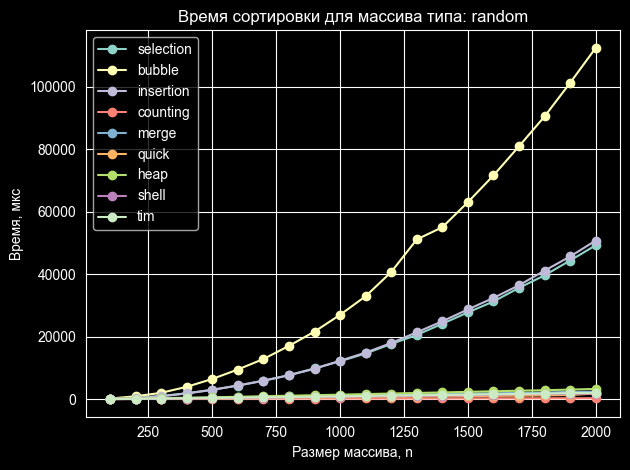

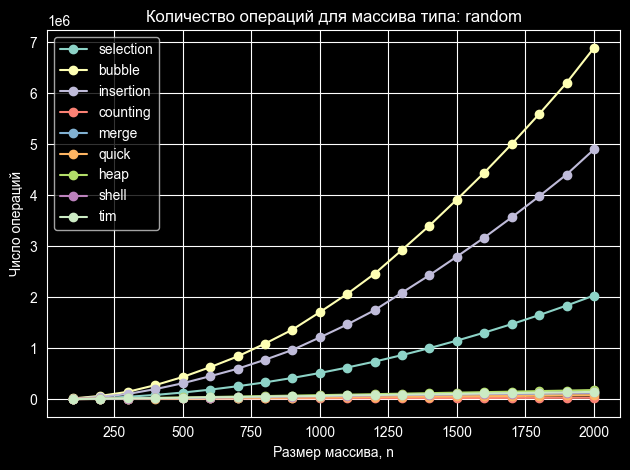

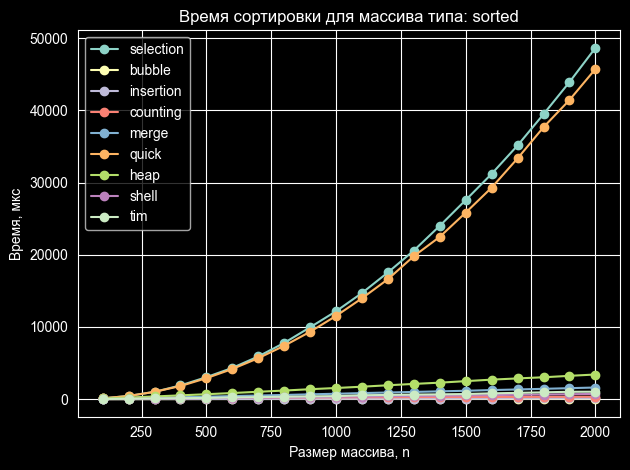

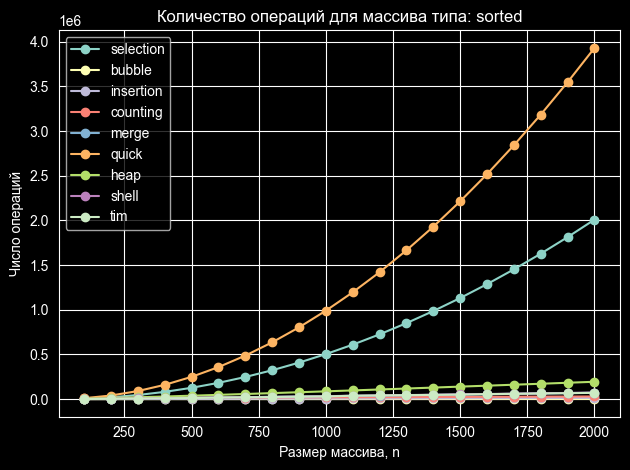

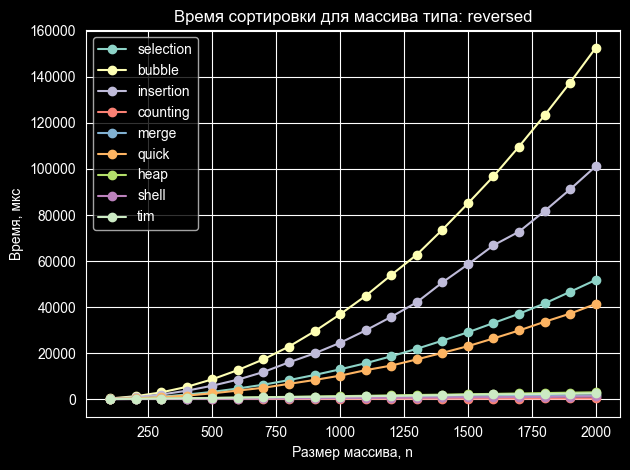

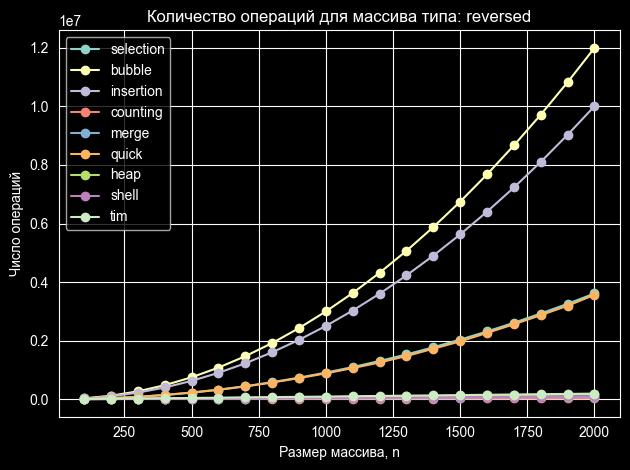

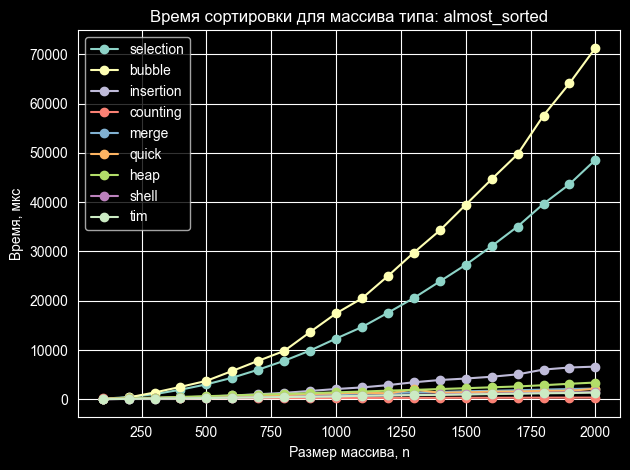

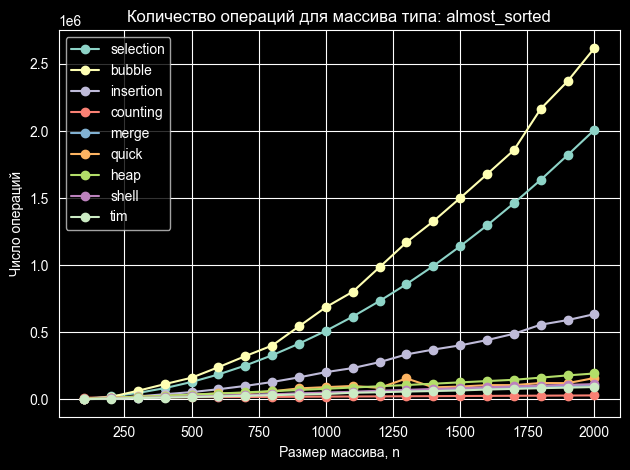

In [24]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print("matplotlib не установлен: графики не построены.")

if plt is not None:
    # I. Для каждого вида массива: график времени и график операций
    for array_type_name in unique_result_values("array_type"):
        rows_sub = filter_results(array_type=array_type_name)
        plt.figure()
        for alg in unique_result_values("algorithm", rows_sub):
            data = sorted(filter_results(rows_sub, algorithm=alg), key=lambda row: row["n"])
            plt.plot(
                [row["n"] for row in data],
                [row["time_us"] for row in data],
                marker="o",
                label=alg,
            )
        plt.xlabel("Размер массива, n")
        plt.ylabel("Время, мкс")
        plt.title(f"Время сортировки для массива типа: {array_type_name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # График операций
        plt.figure()
        for alg in unique_result_values("algorithm", rows_sub):
            data = sorted(filter_results(rows_sub, algorithm=alg), key=lambda row: row["n"])
            plt.plot(
                [row["n"] for row in data],
                [row["ops"] for row in data],
                marker="o",
                label=alg,
            )
        plt.xlabel("Размер массива, n")
        plt.ylabel("Число операций")
        plt.title(f"Количество операций для массива типа: {array_type_name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()


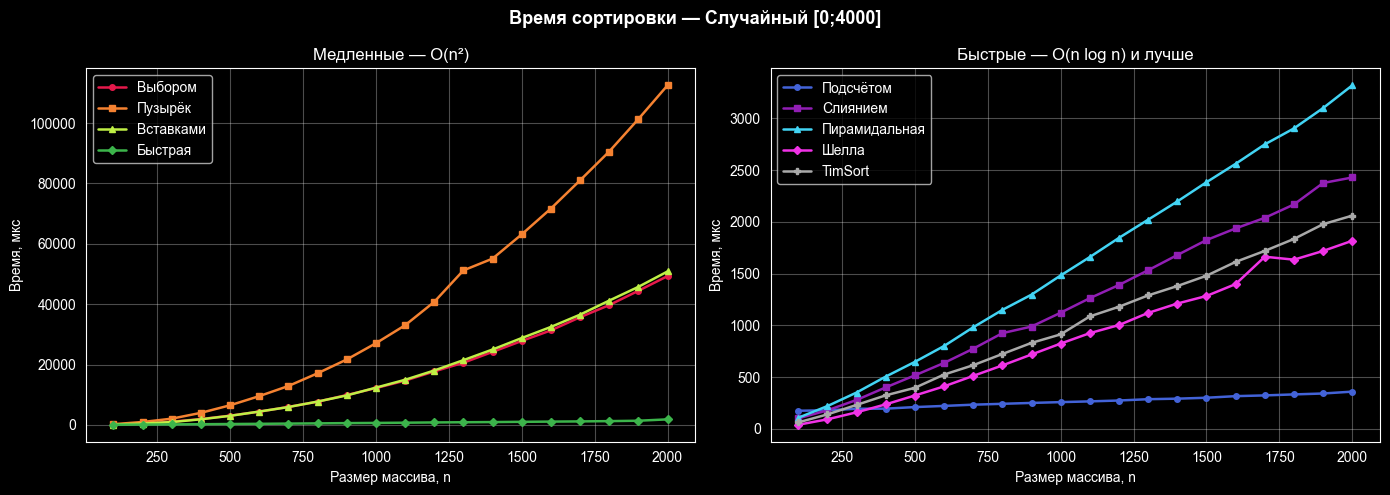

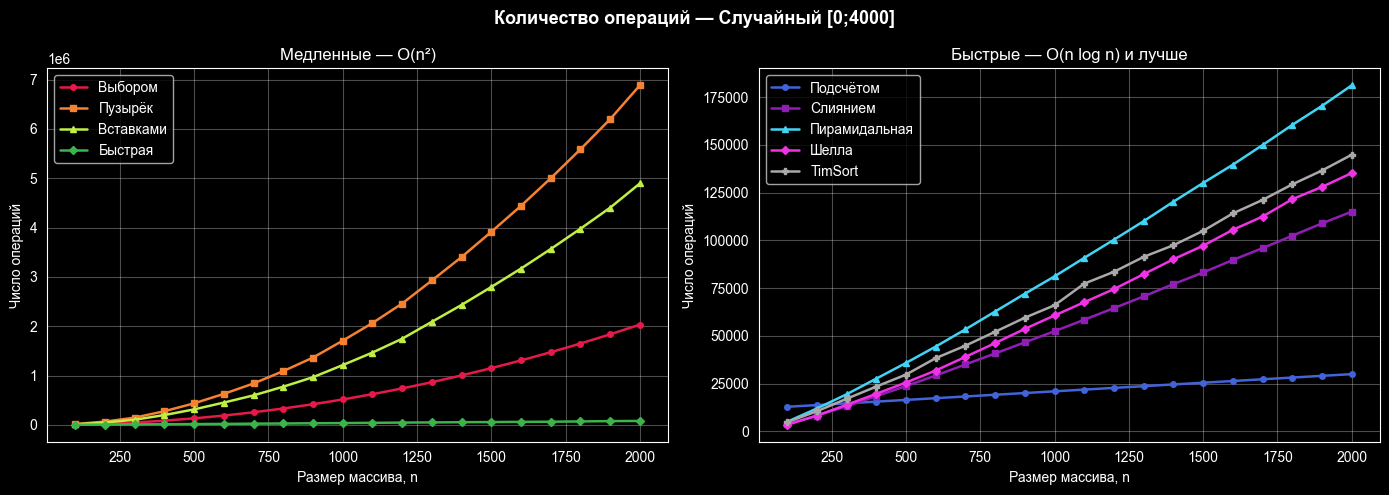

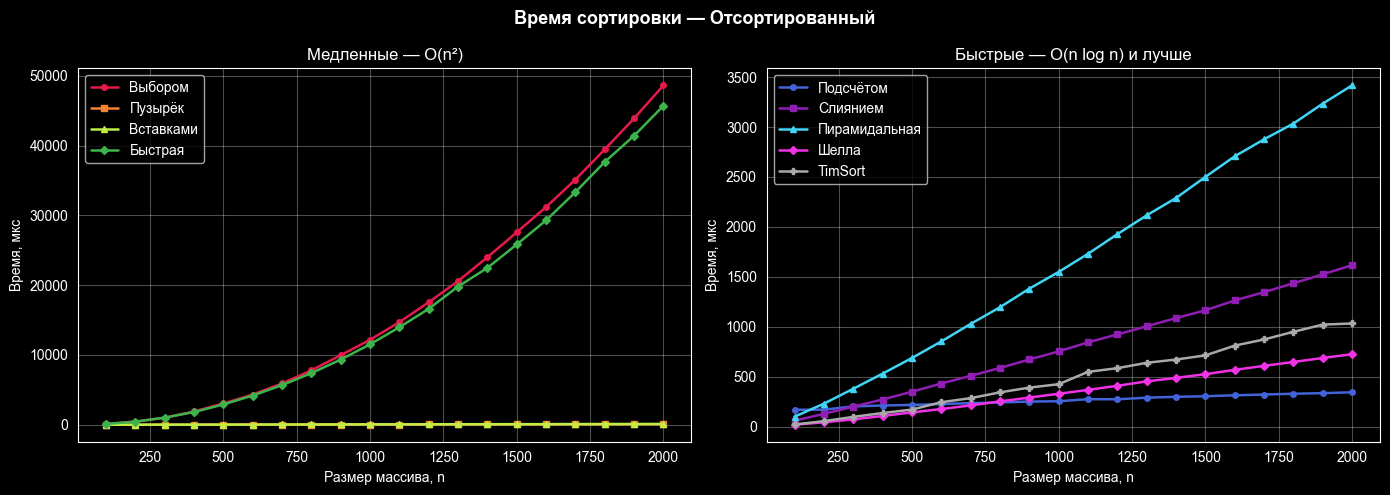

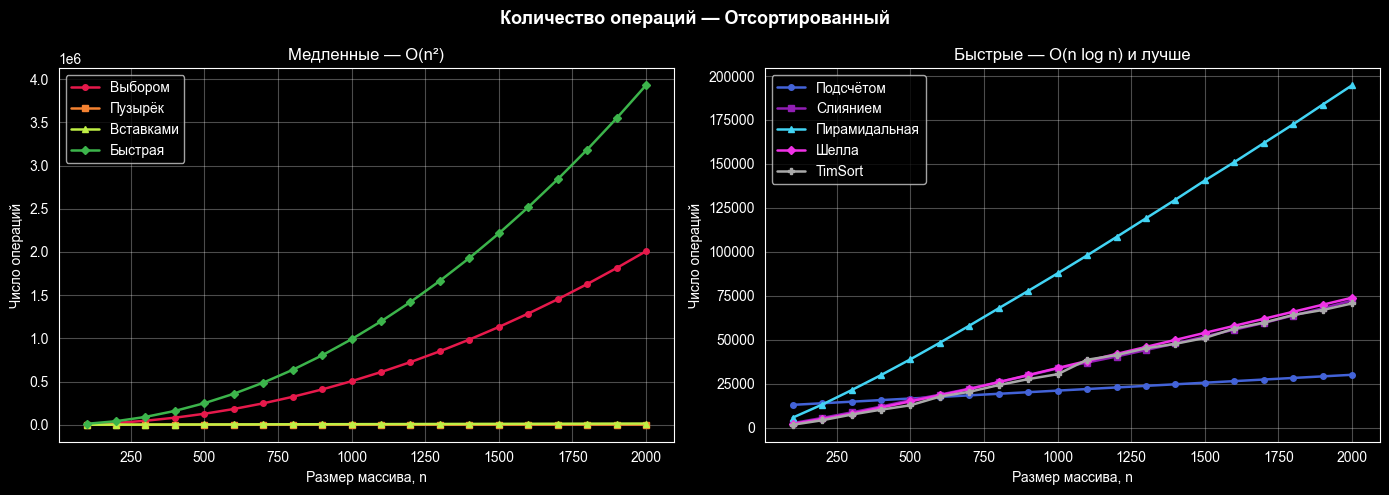

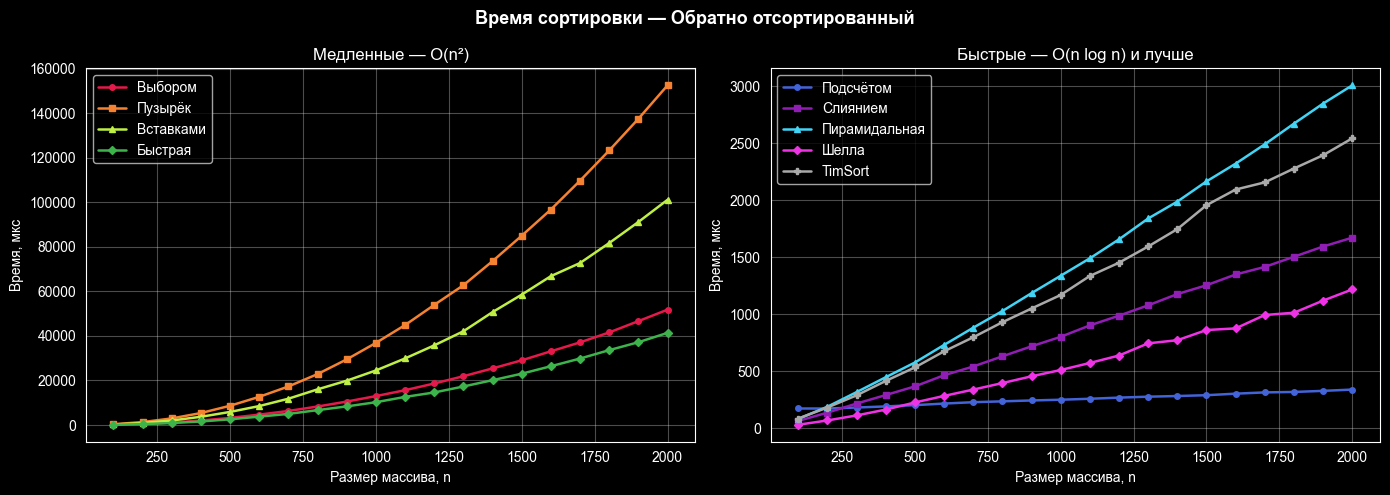

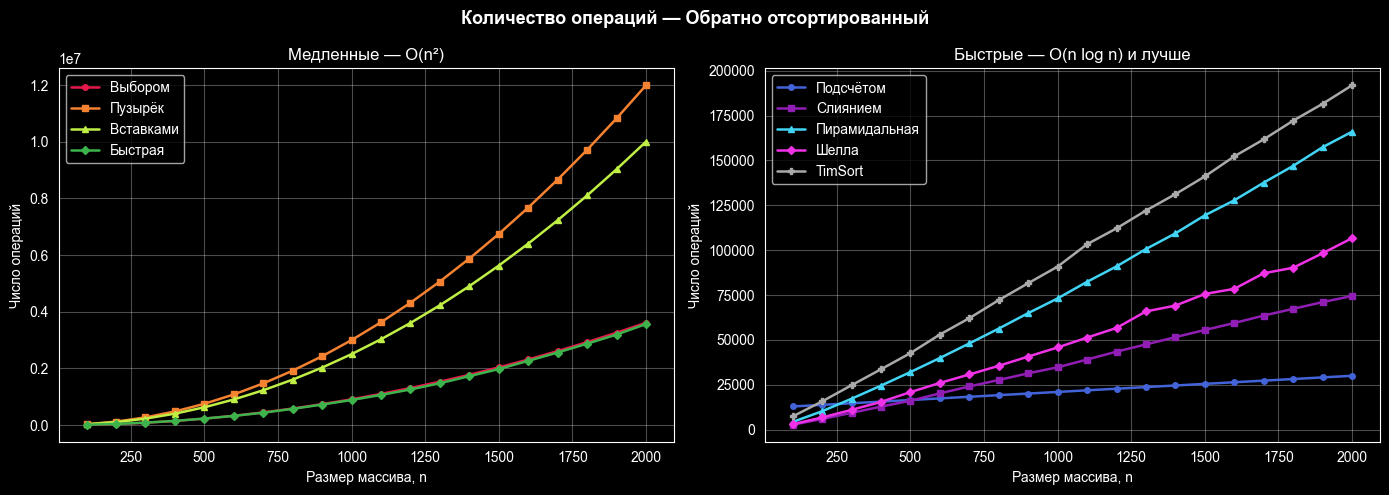

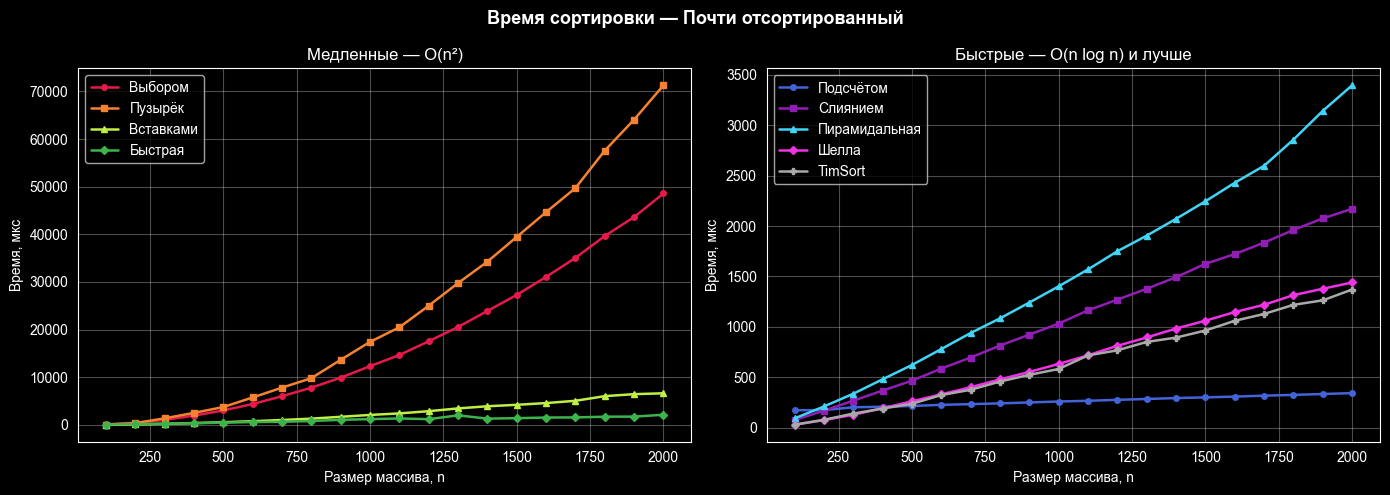

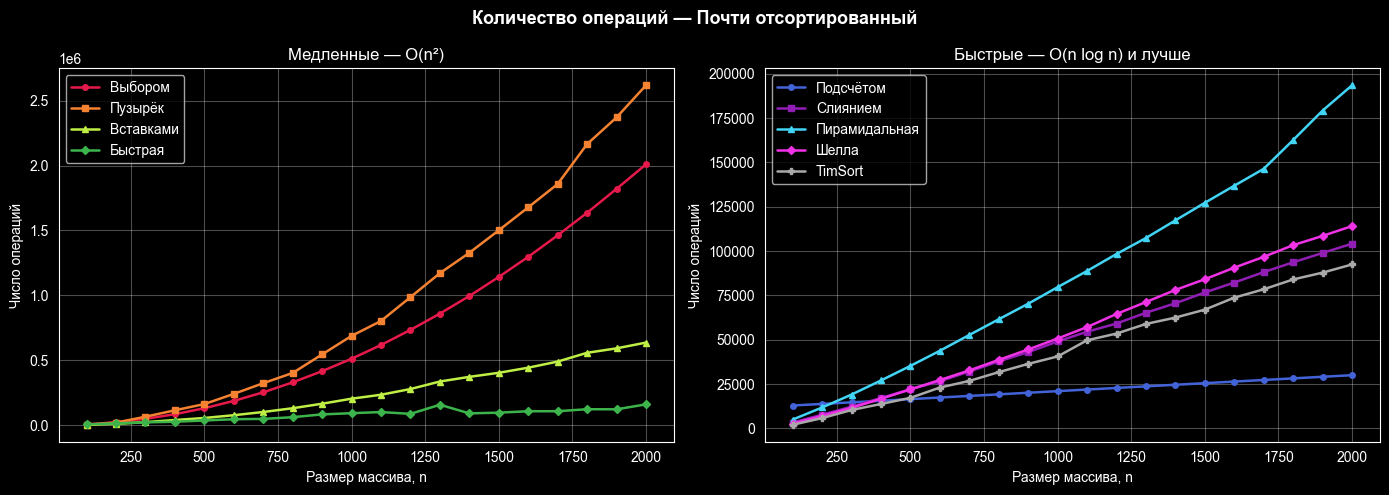

In [25]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print("matplotlib не установлен: графики не построены.")

if plt is not None:
    # --- Настройки отображения ---

    ALG_LABELS = {
        "selection": "Выбором",
        "bubble":    "Пузырек",
        "insertion": "Вставками",
        "counting":  "Подсчетом",
        "merge":     "Слиянием",
        "quick":     "Быстрая",
        "heap":      "Пирамидальная",
        "shell":     "Шелла",
        "tim":       "TimSort",
    }
    ARRAY_LABELS = {
        "random":        "Случайный [0;4000]",
        "sorted":        "Отсортированный",
        "reversed":      "Обратно отсортированный",
        "almost_sorted": "Почти отсортированный",
    }

    SLOW_ALGS = ["selection", "bubble", "insertion", "quick"]
    FAST_ALGS = ["counting", "merge", "heap", "shell", "tim"]

    ALG_COLORS = {
        "selection": "#e6194b",
        "bubble":    "#f58231",
        "insertion": "#bfef45",
        "quick":     "#3cb44b",
        "counting":  "#4363d8",
        "merge":     "#911eb4",
        "heap":      "#42d4f4",
        "shell":     "#f032e6",
        "tim":       "#a9a9a9",
    }
    ALG_MARKERS = {
        "selection": "o", "bubble": "s", "insertion": "^", "quick": "D",
        "counting":  "o", "merge":  "s", "heap":      "^", "shell": "D", "tim": "P",
    }

    # --- Набор I: для каждого типа массива — все алгоритмы ---

    for array_type in ["random", "sorted", "reversed", "almost_sorted"]:
        rows_arr = filter_results(array_type=array_type)
        title_arr = ARRAY_LABELS[array_type]

        for metric, ylabel, title_suffix in [
            ("time_us", "Время, мкс",     "Время сортировки"),
            ("ops",     "Число операций", "Количество операций"),
        ]:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f"{title_suffix} — {title_arr}", fontsize=13, fontweight="bold")

            for alg in SLOW_ALGS:
                data = sorted(filter_results(rows_arr, algorithm=alg), key=lambda row: row["n"])
                ax1.plot(
                    [row["n"] for row in data],
                    [row[metric] for row in data],
                    marker=ALG_MARKERS[alg],
                    color=ALG_COLORS[alg],
                    label=ALG_LABELS[alg],
                    linewidth=1.8,
                    markersize=4,
                )
            ax1.set_title("Медленные — O(n²)")
            ax1.set_xlabel("Размер массива, n")
            ax1.set_ylabel(ylabel)
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            for alg in FAST_ALGS:
                data = sorted(filter_results(rows_arr, algorithm=alg), key=lambda row: row["n"])
                ax2.plot(
                    [row["n"] for row in data],
                    [row[metric] for row in data],
                    marker=ALG_MARKERS[alg],
                    color=ALG_COLORS[alg],
                    label=ALG_LABELS[alg],
                    linewidth=1.8,
                    markersize=4,
                )
            ax2.set_title("Быстрые — O(n log n) и лучше")
            ax2.set_xlabel("Размер массива, n")
            ax2.set_ylabel(ylabel)
            ax2.legend()
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()


## **9. Что сделано**

* В ноутбуке реализованы и исследованы 9 алгоритмов сортировки: выбором, пузырьком с условием Айверсона, вставками, подсчетом, слиянием, быстрая сортировка с первым опорным элементом и разбиением Хоара, пирамидальная сортировка, сортировка Шелла с последовательностью Циура и TimSort.

* Для каждого алгоритма написаны две версии: обычная версия для измерения времени выполнения и версия со счетчиком элементарных операций. Были подготовлены 4 типа входных массивов: случайный, отсортированный, обратно отсортированный и почти отсортированный. Размеры массивов изменялись от 100 до 2000 с шагом 100.

* Для измерения времени использовался timeit, каждый запуск усреднялся по 30 повторам. Для подсчета операций использовались отдельные функции с явными счетчиками. Результаты экспериментов были собраны для всех алгоритмов,  типов массивов и размеров, после чего сохранены в файл results.csv.

* Также были построены графики зависимости времени выполнения и количества элементарных операций от размера массива. Для удобства алгоритмы на графиках разделены на медленные квадратичные и более быстрые алгоритмы. В результате получены данные для дальнейшего сравнения сложности и анализа поведения сортировок на разных типах входных массивов.


## **8. Анализ полученных результатов**

Заполните таблицу

| Алгоритм                                           | Лучшая сложность | Средняя | Худшая | Память | Устойчивость | Применимость / Примечания / Почему когда-то хуже, какие данные хорошие и плохие |
| -------------------------------------------------- | ---------------- | ------- | ------ | ------ | ------------ | ------------------------- |
| **1. Сортировка выбором**                          |                  |         |        |        |              |                           |
| **2. Пузырьковая**                                 |                  |         |        |        |              |                           |
| **3. Простые вставки**                             |                  |         |        |        |              |                           |
| **4. Сортировка подсчетом**                        |                  |         |        |        |              |                           |
| **5. Сортировка слиянием**                         |                  |         |        |        |              |                           |
| **6. Быстрая сортировка (опорный — первый, Хоар)** |                  |         |        |        |              |                           |
| **7. Пирамидальная сортировка**                    |                  |         |        |        |              |                           |
| **8. Сортировка Шелла (Циур)**                     |                  |         |        |        |              |                           |
| **9. TimSort** **                                     |                  |         |        |        |              |                           |



*На графике X видно, что на почти отсортированных данных Insertion Sort работает рядом с O(n), а Bubble все еще показывает квадратичную зависимость…*

Ответьте еще на вопросы:
1. Почему выбросы есть?
* потому что
2. Почему мы делаем повторы при измерении времени?
* потому что